In [45]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

file_path = 'Clean_Dataset.csv';
df = pd.read_csv(file_path)

In [46]:
df.head(7)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060


In [47]:
df.drop(columns=['flight','Unnamed: 0'], errors='ignore', inplace=True)

In [48]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [49]:
df.shape

(300153, 10)

In [50]:
df.columns.tolist()

['airline',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class',
 'duration',
 'days_left',
 'price']

In [51]:
df.dtypes

airline              object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

In [52]:
df.isnull().sum()

airline             0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [53]:
df['price'].describe()

count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

In [54]:
df['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [55]:
df['stops'].value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

In [56]:
df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

## Dataset Visualization & Insights

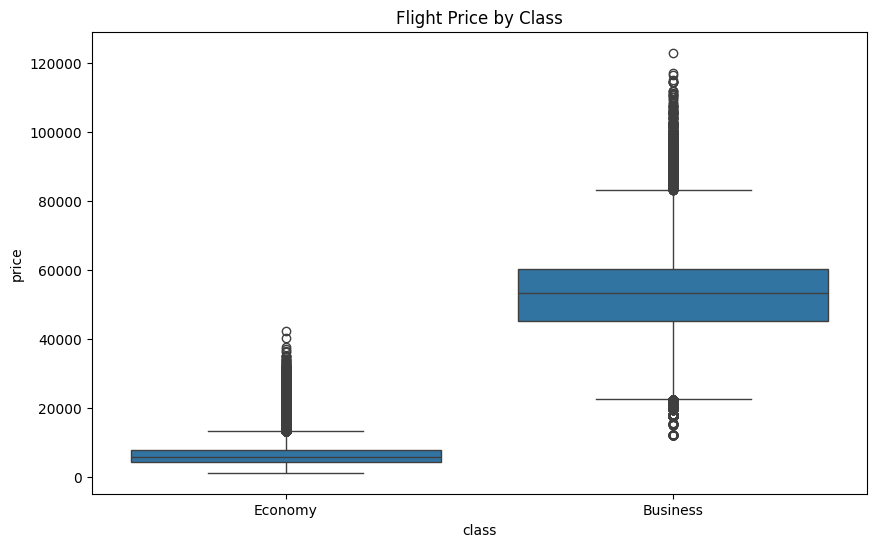

In [57]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='class', y='price')
plt.title("Flight Price by Class")
plt.show()

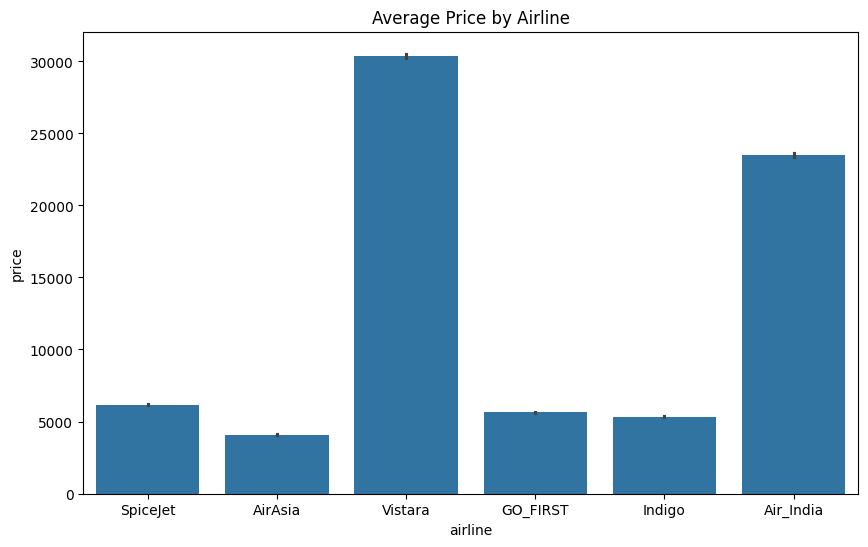

In [58]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='airline', y='price')
plt.title("Average Price by Airline")
plt.show()

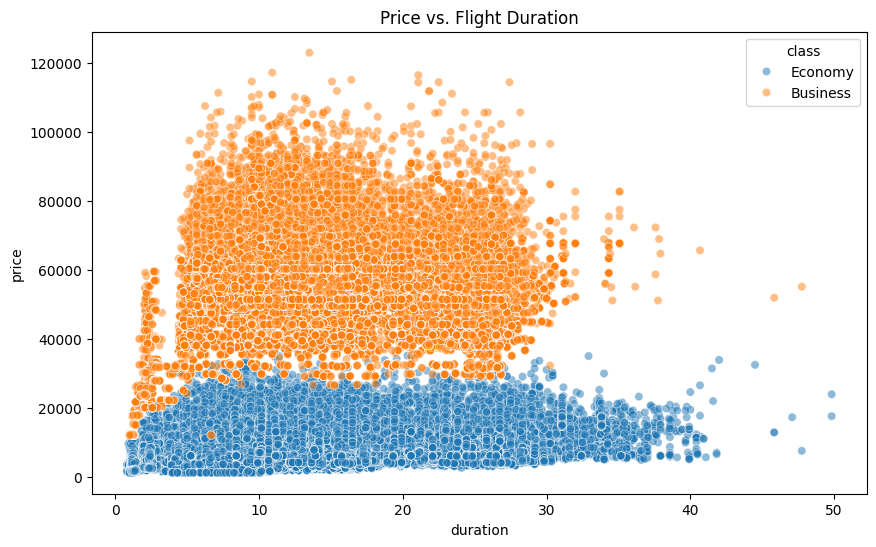

In [59]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='duration', y='price', hue='class', alpha=0.5)
plt.title("Price vs. Flight Duration")
plt.show()

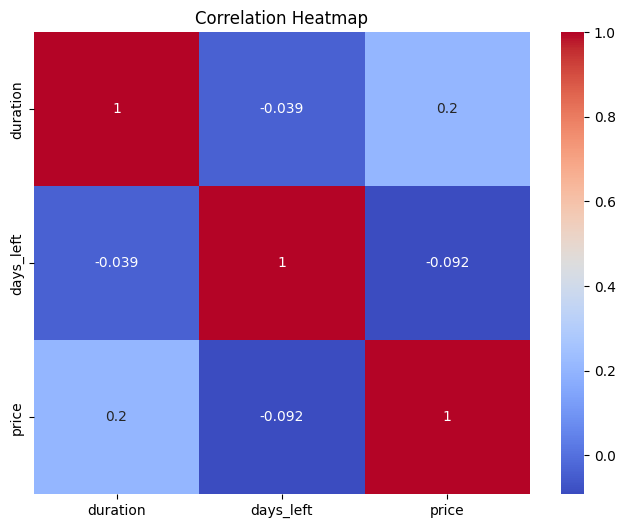

In [60]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['duration', 'days_left', 'price']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

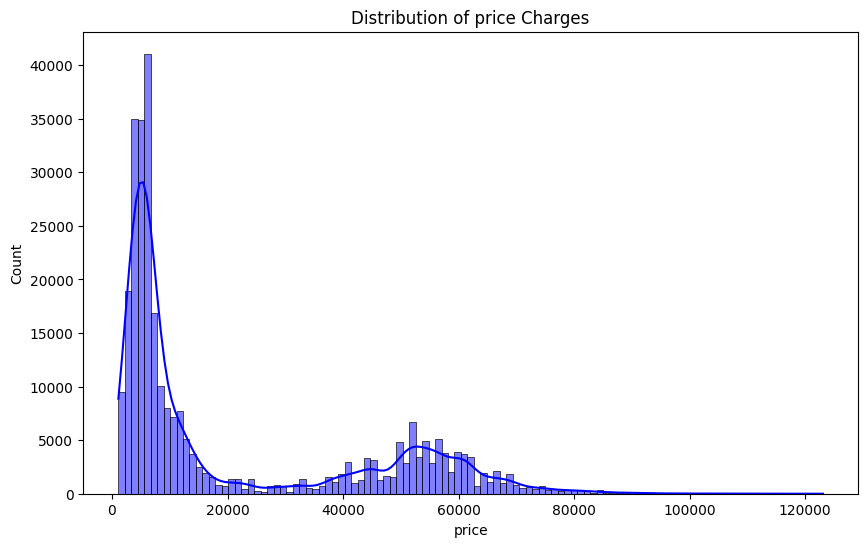

In [61]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="price",kde=True,color="blue")
plt.title("Distribution of price Charges")
plt.show()

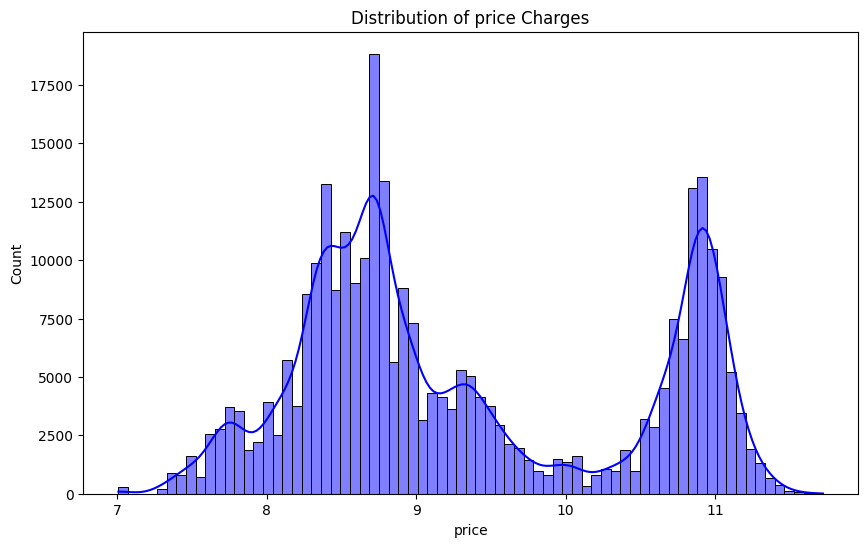

In [62]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x=np.log1p(df['price']),kde=True,color="blue")
plt.title("Distribution of price Charges")
plt.show()

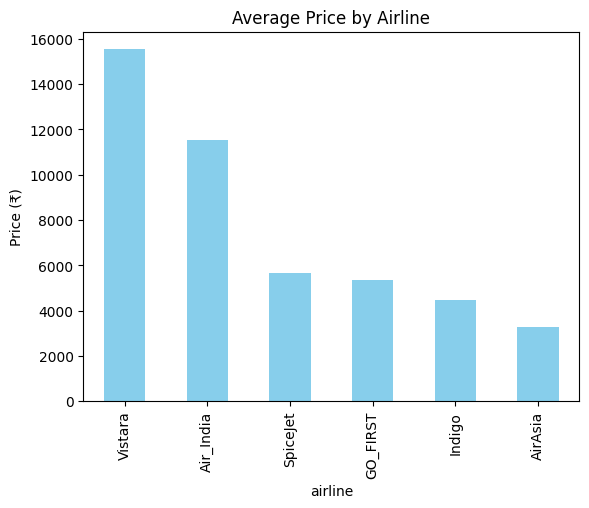

In [63]:
# 1. Do the math manually first
airline_prices = df.groupby('airline')['price'].median().sort_values(ascending=False)

# 2. Plot the result
airline_prices.plot.bar(color='skyblue')
plt.title("Average Price by Airline")
plt.ylabel("Price (₹)")
plt.show()

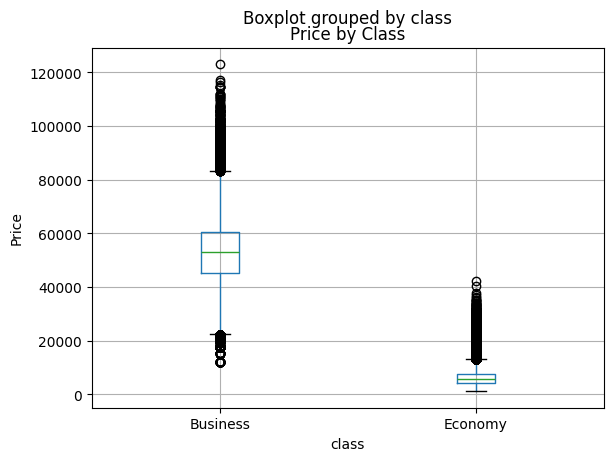

In [64]:
df.boxplot(column='price', by='class')
plt.title("Price by Class")
plt.ylabel("Price")
plt.show()

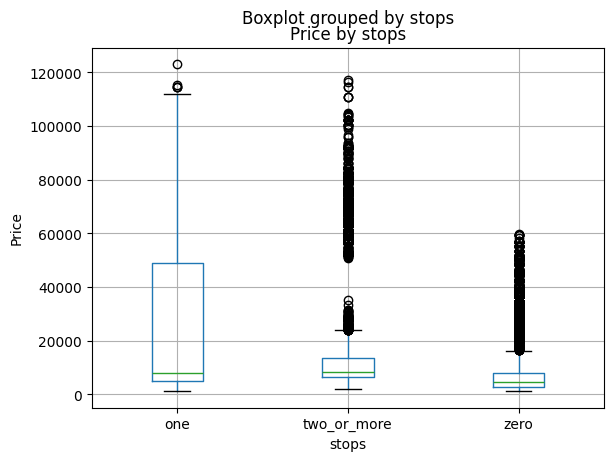

In [65]:
df.boxplot(column='price', by='stops')
plt.title("Price by stops")
plt.ylabel("Price")
plt.show()

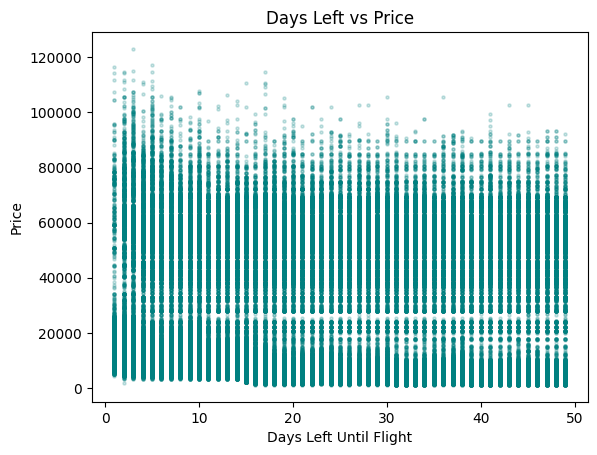

In [66]:
plt.scatter(df['days_left'], df['price'], alpha=0.2, s=5, color='teal')
plt.title("Days Left vs Price")
plt.ylabel("Price")
plt.xlabel("Days Left Until Flight")
plt.show()

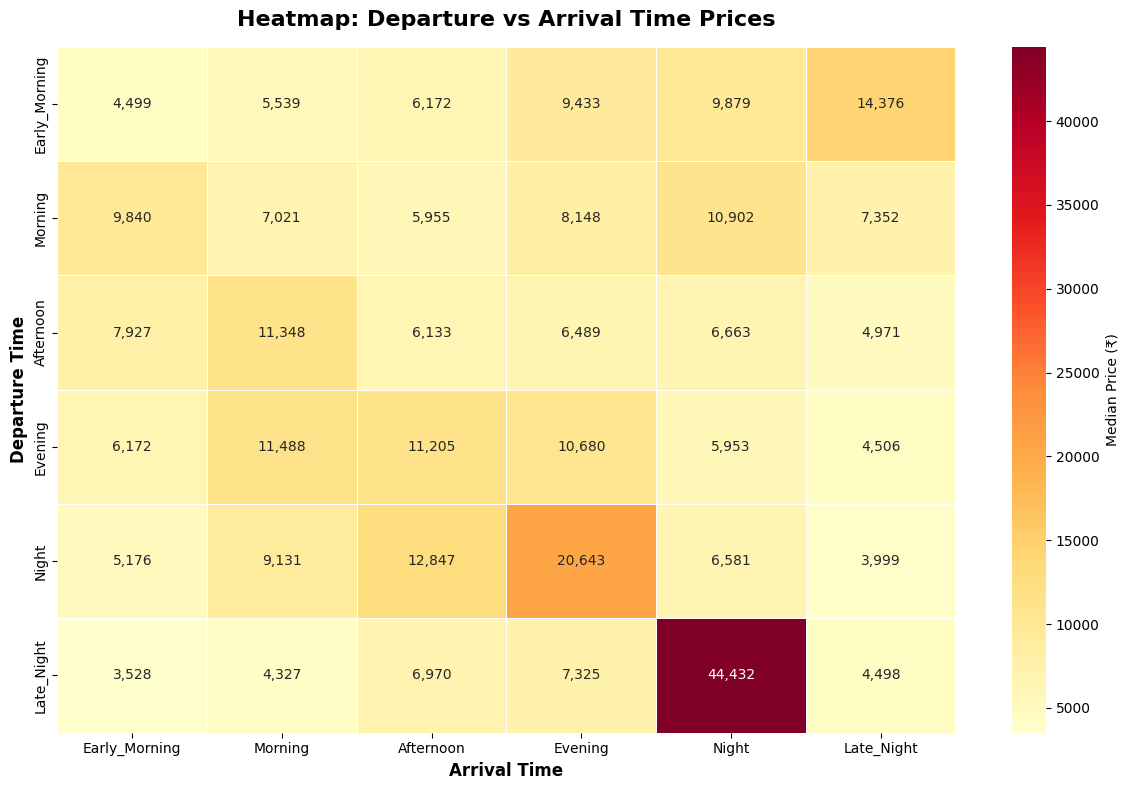

In [67]:
time_order = ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']
time_pivot = df.pivot_table(
    values='price', 
    index='departure_time', 
    columns='arrival_time', 
    aggfunc='median'
)

valid_idx = [t for t in time_order if t in time_pivot.index]
valid_col = [t for t in time_order if t in time_pivot.columns]
time_pivot = time_pivot.loc[valid_idx, valid_col]
plt.figure(figsize=(12, 8))

sns.heatmap(time_pivot, annot=True, fmt=",.0f", cmap="YlOrRd", 
            linewidths=0.5, cbar_kws={'label': 'Median Price (₹)'})

plt.title("Heatmap: Departure vs Arrival Time Prices", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Arrival Time", fontsize=12, fontweight='bold')
plt.ylabel("Departure Time", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

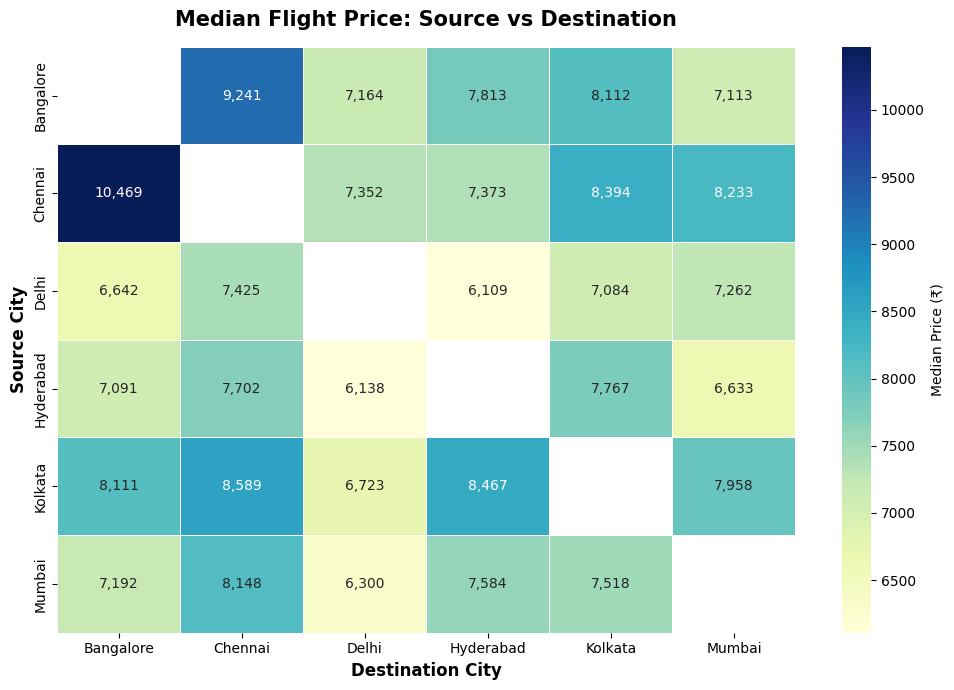

In [68]:
route_pivot = df.pivot_table(
    values='price', 
    index='source_city', 
    columns='destination_city', 
    aggfunc='median'
)

# 2. Plot the Heatmap!
plt.figure(figsize=(10, 7))

# We use a blue/green color map here to differentiate it from the Time heatmap!
sns.heatmap(route_pivot, annot=True, fmt=",.0f", cmap="YlGnBu", 
            linewidths=0.5, cbar_kws={'label': 'Median Price (₹)'})

plt.title("Median Flight Price: Source vs Destination", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Destination City", fontsize=12, fontweight='bold')
plt.ylabel("Source City", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

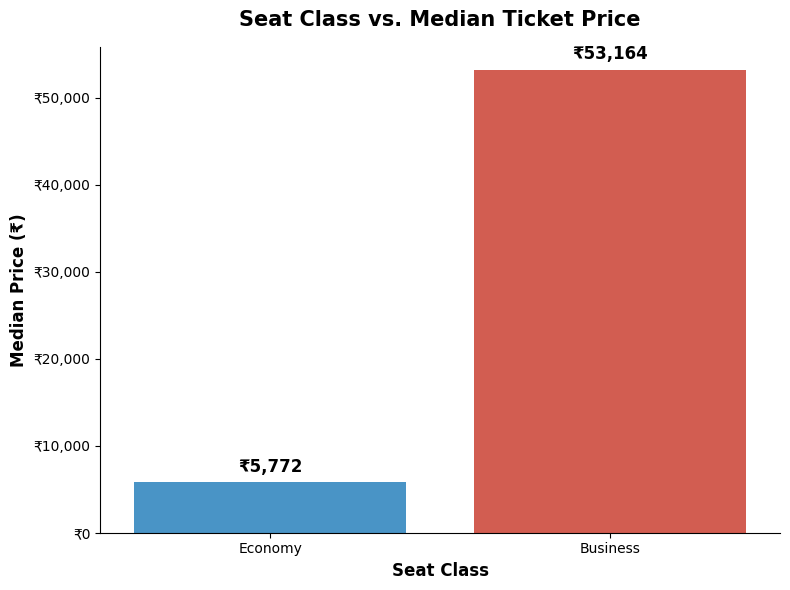

In [69]:
plt.figure(figsize=(8, 6))

# 1. Create a simple bar chart comparing the median price of the two classes
ax = sns.barplot(
    data=df, 
    x='class', 
    y='price', 
    estimator=np.median, 
    errorbar=None,
    palette=['#3498DB', '#E74C3C'] # Blue for Economy, Red for Business
)

# 2. Add exact Rupee text labels on top of the bars
for p in ax.patches:
    ax.annotate(f'₹{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')

# 3. Clean up the titles and axes
plt.title("Seat Class vs. Median Ticket Price", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Seat Class", fontsize=12, fontweight='bold')
plt.ylabel("Median Price (₹)", fontsize=12, fontweight='bold')

# Format Y-axis to show Rupees cleanly
formatter = FuncFormatter(lambda y, pos: f'₹{int(y):,}')
plt.gca().yaxis.set_major_formatter(formatter)

sns.despine()
plt.tight_layout()
plt.show()

# Data Cleaning & Outlier Strategy

Running df.info() reveals a perfectly clean structural framework with zero missing values across all columns. No imputation steps are required.

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   source_city       300153 non-null  object 
 2   departure_time    300153 non-null  object 
 3   stops             300153 non-null  object 
 4   arrival_time      300153 non-null  object 
 5   destination_city  300153 non-null  object 
 6   class             300153 non-null  object 
 7   duration          300153 non-null  float64
 8   days_left         300153 non-null  int64  
 9   price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 22.9+ MB


In [71]:
before=len(df)
q1  = df['price'].quantile(0.005)
q99 = df['price'].quantile(0.995)
df  = df[(df['price'] >= q1) & (df['price'] <= q99)]
print(f"Rows before outlier removal : {before}")
print(f"Rows after  outlier removal : {len(df)}")
print(f"Removed {before - len(df)} extreme price rows (bottom 0.5% / top 0.5%)")

Rows before outlier removal : 300153
Rows after  outlier removal : 297174
Removed 2979 extreme price rows (bottom 0.5% / top 0.5%)


## Functions Transformation

In [72]:
skew_before = df['price'].skew()
df['price_log'] = np.log1p(df['price'])
skew_after  = df['price_log'].skew()
print(f"Price skewness BEFORE log transform : {skew_before:.4f}")
print(f"Price skewness AFTER  log transform : {skew_after:.4f}")
print("(Closer to 0 = more normal = better for linear regression)")

Price skewness BEFORE log transform : 1.0274
Price skewness AFTER  log transform : 0.4241
(Closer to 0 = more normal = better for linear regression)


In [73]:
# Binary Encoding not OHE
df['class_encoded'] = df['class'].map({'Economy': 0, 'Business': 1})
print("Binary encoded  : 'class'  →  Economy=0, Business=1")

Binary encoded  : 'class'  →  Economy=0, Business=1


In [74]:
df.class_encoded.value_counts()

class_encoded
0    205188
1     91986
Name: count, dtype: int64

In [75]:
stops_order = {'zero': 0, 'one': 1, 'two_or_more': 2}
df['stops_encoded'] = df['stops'].map(stops_order)
print("Ordinal encoded : 'stops'  →  zero=0, one=1, two_or_more=2")

Ordinal encoded : 'stops'  →  zero=0, one=1, two_or_more=2


In [76]:
df.stops_encoded.value_counts()

stops_encoded
1    249003
0     35058
2     13113
Name: count, dtype: int64

In [77]:
time_order = {
    'Early_Morning': 0, 'Morning': 1, 'Afternoon': 2,
    'Evening': 3, 'Night': 4, 'Late_Night': 5
}
df['dep_time_encoded'] = df['departure_time'].map(time_order)
df['arr_time_encoded'] = df['arrival_time'].map(time_order)
print("Ordinal encoded : 'departure_time' and 'arrival_time'")

Ordinal encoded : 'departure_time' and 'arrival_time'


In [78]:
df = pd.get_dummies(df,
    columns=['airline', 'source_city', 'destination_city'],
    drop_first=True)
print("One-Hot encoded : 'airline', 'source_city', 'destination_city'")

One-Hot encoded : 'airline', 'source_city', 'destination_city'


## Feature Construction

In [79]:
df['duration_mins'] = (df['duration'] * 60).astype(int)
print("New feature: 'duration_mins' = duration × 60")
 
# Is it a direct flight?
df['is_direct'] = (df['stops_encoded'] == 0).astype(int)
print("New feature: 'is_direct'  →  1 if zero stops, else 0")
 
# Booking window category encoded as number
df['booking_window'] = pd.cut(
    df['days_left'],
    bins=[0, 7, 14, 30, 60, 999],
    labels=[0, 1, 2, 3, 4]
).astype(int)
print("New feature: 'booking_window'  →  binned days_left into 5 categories")
 
# Time gap between departure and arrival bins
df['time_shift'] = df['arr_time_encoded'] - df['dep_time_encoded']
print("New feature: 'time_shift'  →  arrival_time_bin − departure_time_bin")
 
print(f"\nDataset shape after feature construction: {df.shape}")

New feature: 'duration_mins' = duration × 60
New feature: 'is_direct'  →  1 if zero stops, else 0
New feature: 'booking_window'  →  binned days_left into 5 categories
New feature: 'time_shift'  →  arrival_time_bin − departure_time_bin

Dataset shape after feature construction: (297174, 31)


## FEATURE SELECTION — Drop Raw Columns

In [80]:
cols_to_drop = [
    'departure_time', 'arrival_time', 'stops',
    'class', 'duration', 'price' 
]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [81]:
df.head()

,days_left,price_log,class_encoded,stops_encoded,dep_time_encoded,arr_time_encoded,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,source_city_Mumbai,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,duration_mins,is_direct,booking_window,time_shift
0,1,8.691819,0,0,3,4,False,False,False,True,...,False,False,False,False,False,True,130,1,0,1
1,1,8.691819,0,0,0,1,False,False,False,True,...,False,False,False,False,False,True,139,1,0,1
2,1,8.692322,0,0,0,0,False,False,False,False,...,False,False,False,False,False,True,130,1,0,0
3,1,8.692154,0,0,1,2,False,False,False,False,...,False,False,False,False,False,True,135,1,0,1
4,1,8.692154,0,0,1,1,False,False,False,False,...,False,False,False,False,False,True,139,1,0,0


In [82]:
target = 'price_log'
X = df.drop(columns=[target])
y = df[target]

## TRAIN TEST SPLIT , PIPELINE (Scaling + PCA + Model), EVALUATION

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
# Identify numeric columns for scaling
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
 
# ColumnTransformer: scale only numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
pipe_pca = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),
    ('model', LinearRegression())
])
pipe_lr.fit(X_train, y_train)
pipe_pca.fit(X_train, y_train)

# Build and Train Polynomial Regression Pipeline
# Note: degree=2 is used to avoid a massive spike in dimensionality and memory usage
pipe_poly = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])
pipe_poly.fit(X_train, y_train)

# Build and Train K-Nearest Neighbors Pipeline
pipe_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=5)) # 5 is the default, can be tuned
])
pipe_knn.fit(X_train, y_train)

# 1. Build and Train Random Forest Pipeline
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)

# 2. Build and Train AdaBoost Pipeline
pipe_ada = Pipeline([
    ('preprocessor', preprocessor),
    ('model', AdaBoostRegressor(n_estimators=100, random_state=42))
])
pipe_ada.fit(X_train, y_train)

# 3. Build and Train XGBoost Pipeline
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
pipe_xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [85]:
def evaluate(pipe, X_test, y_test, label):
    y_pred_log = pipe.predict(X_test)
    # Convert back from log scale to actual ₹ prices
    y_pred   = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)
 
    mae  = mean_absolute_error(y_actual, y_pred)
    rmse = mean_squared_error(y_actual, y_pred) ** 0.5
    r2   = r2_score(y_actual, y_pred)
 
    print(f"\n  [{label}]")
    print(f"  MAE  (Mean Absolute Error)  : ₹{mae:,.0f}")
    print(f"  RMSE (Root Mean Sq. Error)  : ₹{rmse:,.0f}")
    print(f"  R²   (R-squared)            : {r2:.4f}")
    print(f"  Interpretation: On average, predictions are off by ₹{mae:,.0f}")
 
    return y_pred, y_actual
 
pred_lr,  actual_lr  = evaluate(pipe_lr,  X_test, y_test, "Linear Regression (No PCA)")
pred_pca, actual_pca = evaluate(pipe_pca, X_test, y_test, "Linear Regression + PCA")
pred_poly, actual_poly = evaluate(pipe_poly, X_test, y_test, "Polynomial Regression")
pred_knn, actual_knn = evaluate(pipe_knn, X_test, y_test, "K-Nearest Neighbors")
pred_rf, actual_rf = evaluate(pipe_rf, X_test, y_test, "Random Forest")
pred_ada, actual_ada = evaluate(pipe_ada, X_test, y_test, "AdaBoost")
pred_xgb, actual_xgb = evaluate(pipe_xgb, X_test, y_test, "XGBoost")


  [Linear Regression (No PCA)]
  MAE  (Mean Absolute Error)  : ₹4,536
  RMSE (Root Mean Sq. Error)  : ₹7,983
  R²   (R-squared)            : 0.8711
  Interpretation: On average, predictions are off by ₹4,536

  [Linear Regression + PCA]
  MAE  (Mean Absolute Error)  : ₹4,618
  RMSE (Root Mean Sq. Error)  : ₹7,936
  R²   (R-squared)            : 0.8726
  Interpretation: On average, predictions are off by ₹4,618

  [Polynomial Regression]
  MAE  (Mean Absolute Error)  : ₹3,022
  RMSE (Root Mean Sq. Error)  : ₹5,046
  R²   (R-squared)            : 0.9485
  Interpretation: On average, predictions are off by ₹3,022

  [K-Nearest Neighbors]
  MAE  (Mean Absolute Error)  : ₹1,682
  RMSE (Root Mean Sq. Error)  : ₹3,372
  R²   (R-squared)            : 0.9770
  Interpretation: On average, predictions are off by ₹1,682

  [Random Forest]
  MAE  (Mean Absolute Error)  : ₹959
  RMSE (Root Mean Sq. Error)  : ₹2,401
  R²   (R-squared)            : 0.9883
  Interpretation: On average, predictions are

--- Detailed Performance Comparison ---


,Algorithm,MAE,RMSE,R² Score
4,Random Forest,₹959,"₹2,401",0.9883
2,K-Nearest Neighbors,"₹1,682","₹3,372",0.9770
6,XGBoost,"₹2,042","₹3,578",0.9741
3,Polynomial Regression,"₹3,022","₹5,046",0.9485
5,AdaBoost,"₹3,364","₹5,384",0.9414
1,Linear Regression + PCA,"₹4,618","₹7,936",0.8726
0,Linear Regression,"₹4,536","₹7,983",0.8711


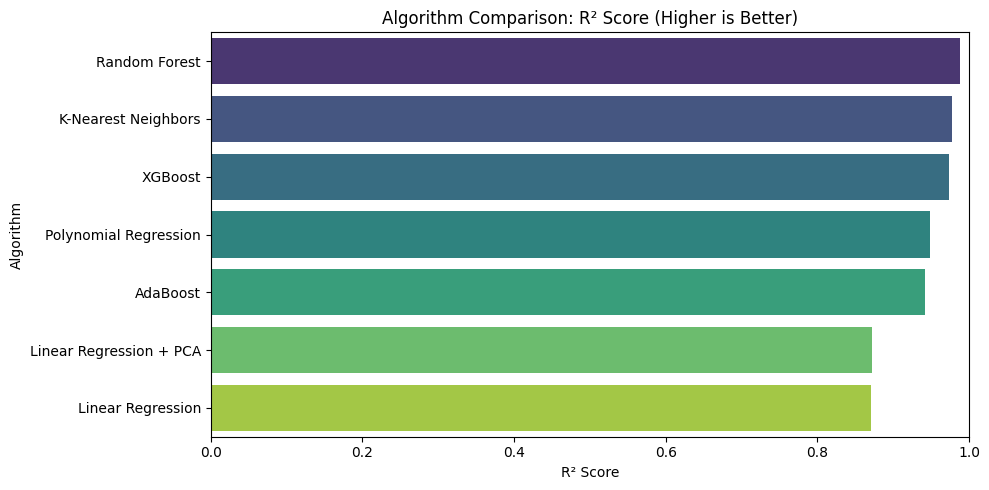

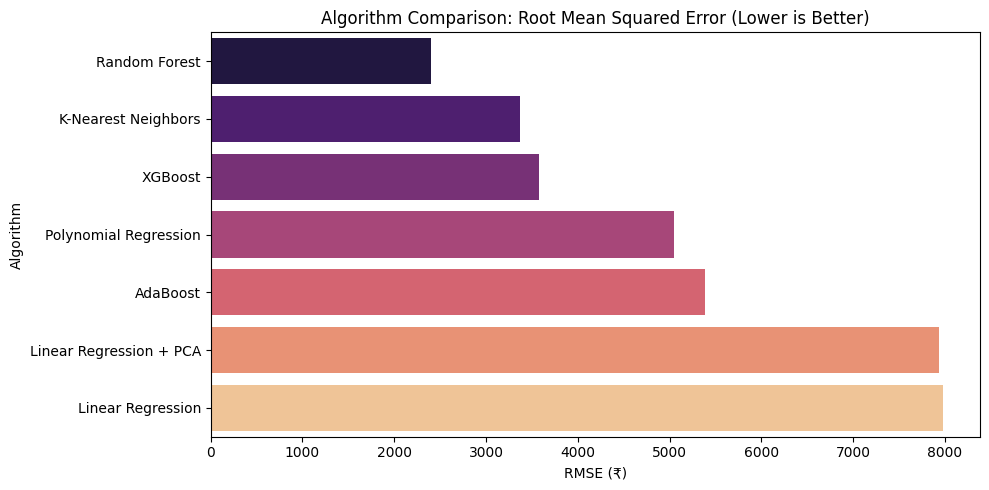

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate all trained pipelines into a dictionary for easy iteration
all_models = {
    "Linear Regression": pipe_lr,
    "Linear Regression + PCA": pipe_pca,
    "K-Nearest Neighbors": pipe_knn,
    "Polynomial Regression": pipe_poly,
    "Random Forest": pipe_rf,
    "AdaBoost": pipe_ada,
    "XGBoost": pipe_xgb
}

results = []

for name, model in all_models.items():
    # Predict and inverse log-transform to get actual ₹ prices
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = mean_squared_error(y_actual, y_pred) ** 0.5
    r2 = r2_score(y_actual, y_pred)
    
    # Append to results list
    results.append({
        'Algorithm': name, 
        'MAE': mae, 
        'RMSE': rmse, 
        'R² Score': r2
    })

# Create a DataFrame and sort by R² Score
comparison_df = pd.DataFrame(results).sort_values(by='R² Score', ascending=False)

# Display the tabular comparison
print("--- Detailed Performance Comparison ---")
display(comparison_df.style.format({
    'MAE': '₹{:,.0f}', 
    'RMSE': '₹{:,.0f}', 
    'R² Score': '{:.4f}'
}))

# ---------------------------------------------------------
# Visualization 1: R² Score Comparison
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='R² Score', y='Algorithm', palette='viridis')
plt.title("Algorithm Comparison: R² Score (Higher is Better)")
plt.xlabel("R² Score")
plt.ylabel("Algorithm")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Visualization 2: RMSE Comparison
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df.sort_values(by='RMSE'), x='RMSE', y='Algorithm', palette='magma')
plt.title("Algorithm Comparison: Root Mean Squared Error (Lower is Better)")
plt.xlabel("RMSE (₹)")
plt.ylabel("Algorithm")
plt.tight_layout()
plt.show()

## FEATURE IMPORTANCE (Coefficients),VISUALISE RESULTS and PREDICT ON A SAMPLE

In [87]:
# 1. Grab the math weights (coefficients) from the trained model
coef = pipe_lr.named_steps['model'].coef_

# 2. Get the exact column names from the preprocessor
# (This is much safer than just using 'numeric_cols')
feat_names = pipe_lr.named_steps['preprocessor'].get_feature_names_out()

# 3. Create a clean Pandas DataFrame and sort by the biggest impact
coef_df = pd.DataFrame({
    'Feature': feat_names[:len(coef)],
    'Coefficient': coef[:len(feat_names)]
})

# 4. Sort by the absolute value (biggest impact, whether positive or negative)
coef_df['Abs_Impact'] = coef_df['Coefficient'].abs()
top_10_features = coef_df.sort_values(by='Abs_Impact', ascending=False).head(10)

# Display the clean table
top_10_features[['Feature', 'Coefficient']]

,Feature,Coefficient
1,scaler__class_encoded,0.935230
13,remainder__airline_Vistara,0.646193
9,remainder__airline_Air_India,0.525078
12,remainder__airline_SpiceJet,0.468198
10,remainder__airline_GO_FIRST,0.417953
11,remainder__airline_Indigo,0.335984
7,scaler__booking_window,-0.182084
17,remainder__source_city_Kolkata,0.136841
22,remainder__destination_city_Kolkata,0.105405
21,remainder__destination_city_Hyderabad,-0.090382


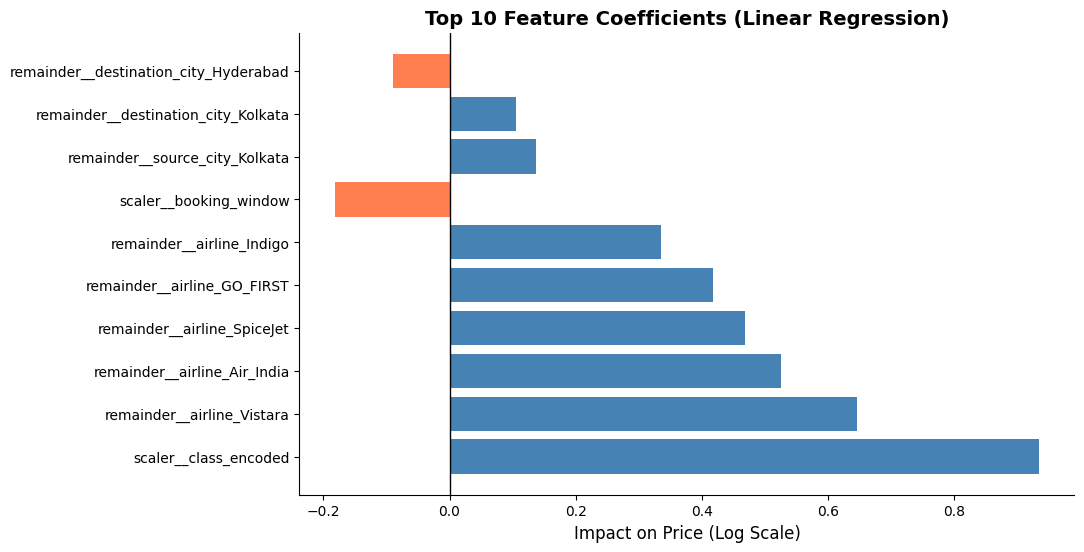

In [88]:
plt.figure(figsize=(10, 6))

# 1. Assign colors: Blue if it increases the price, Red if it decreases the price
colors = ['steelblue' if c > 0 else 'coral' for c in top_10_features['Coefficient']]

# 2. Draw the horizontal bar chart
plt.barh(top_10_features['Feature'], top_10_features['Coefficient'], color=colors)

# 3. Draw a black line at exactly zero for reference
plt.axvline(0, color='black', linewidth=1)

# 4. Add clean titles and labels
plt.title("Top 10 Feature Coefficients (Linear Regression)", fontsize=14, fontweight='bold')
plt.xlabel("Impact on Price (Log Scale)", fontsize=12)

# 5. Show it directly on the screen! (No need to save to a file)
sns.despine()
plt.show()

In [89]:
# 1. Grab the very first row of your testing data
sample_flight = X_test.iloc[[0]]

# 2. Ask the pipeline to predict the price (it returns a log number)
pred_log = pipe_lr.predict(sample_flight)[0]

# 3. Reverse the math (np.expm1) to get the REAL Rupee amounts
pred_price = np.expm1(pred_log)
actual_price = np.expm1(y_test.iloc[0])

# 4. Print the final results nicely
print(f"🎯 ACTUAL Price    : ₹{actual_price:,.2f}")
print(f"🤖 PREDICTED Price : ₹{pred_price:,.2f}")
print("-" * 35)
print(f"⚖️ Difference      : ₹{abs(actual_price - pred_price):,.2f}")

🎯 ACTUAL Price    : ₹9,241.00
🤖 PREDICTED Price : ₹8,344.50
-----------------------------------
⚖️ Difference      : ₹896.50


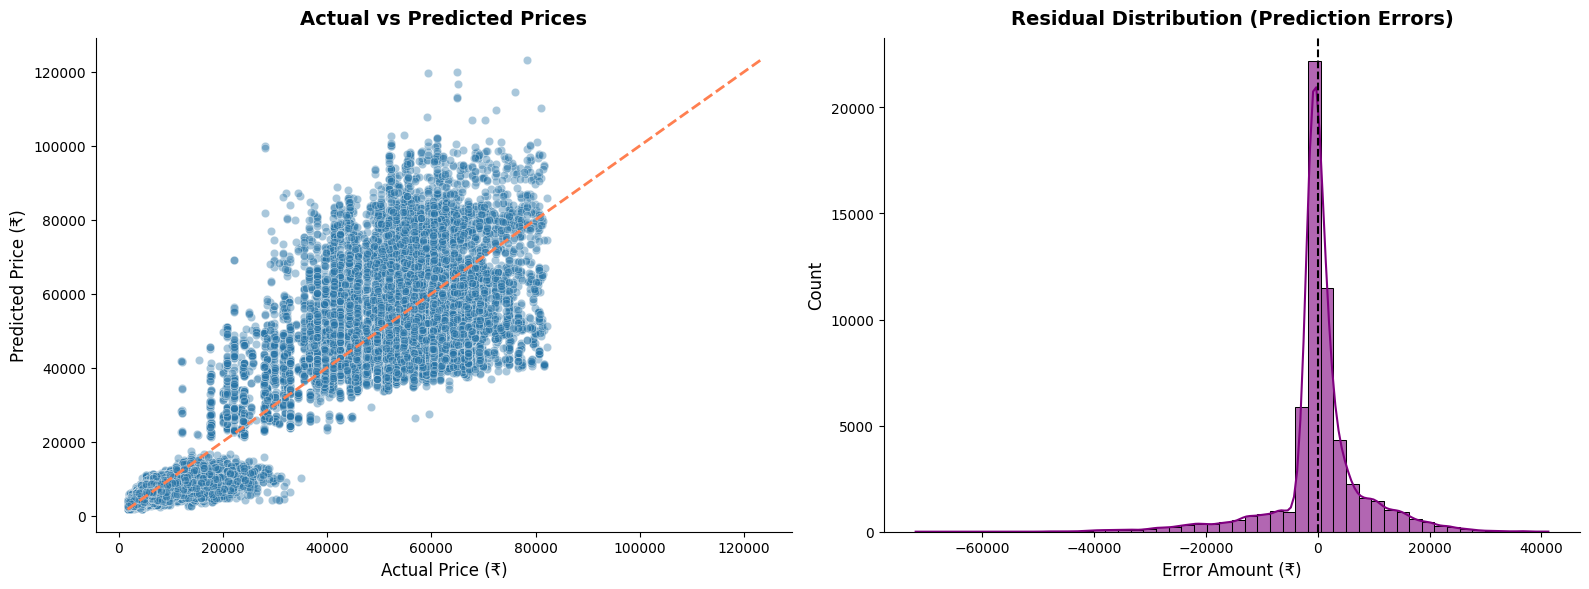

In [90]:
y_pred_log = pipe_lr.predict(X_test)

# 2. Reverse the math to get actual Rupees (since you used log transformation)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# 3. Calculate the residuals (How many Rupees the model was off by)
residuals = y_true - y_pred

# 4. Set up a side-by-side dashboard (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=y_true, y=y_pred, alpha=0.4, color='#2874A6', ax=axes[0])

# Draw the "Perfect Prediction" dashed line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='coral', linestyle='--', linewidth=2)

axes[0].set_title("Actual vs Predicted Prices", fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel("Actual Price (₹)", fontsize=12)
axes[0].set_ylabel("Predicted Price (₹)", fontsize=12)

sns.histplot(residuals, bins=50, kde=True, color='purple', ax=axes[1], alpha=0.6)

# Draw a line at exactly Zero error
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)

axes[1].set_title("Residual Distribution (Prediction Errors)", fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel("Error Amount (₹)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)

# Clean up the borders and show the final dashboard!
sns.despine()
plt.tight_layout()
plt.show()

In [93]:
# 1. Create a blank dataframe using the exact mathematical columns from your test set
my_flight_df = pd.DataFrame(columns=X_test.columns)

# 2. Add one row of all zeros to act as our blank canvas
my_flight_df.loc[0] = 0

# 3. Flip the "switches" (1s) for the text data from your screenshot
# Note: If your notebook used different names for these columns, you may need to adjust them!
if 'airline_SpiceJet' in my_flight_df.columns: my_flight_df['airline_SpiceJet'] = 1
if 'source_city_Delhi' in my_flight_df.columns: my_flight_df['source_city_Delhi'] = 1
if 'destination_city_Mumbai' in my_flight_df.columns: my_flight_df['destination_city_Mumbai'] = 1

# 4. Fill in the numeric data
my_flight_df['days_left'] = 1
my_flight_df['is_direct'] = 1        # Because it has 0 stops
my_flight_df['stops_encoded'] = 0    # 0 stops
my_flight_df['class_encoded'] = 0    # Usually 0 is Economy, 1 is Business

# If your notebook converted duration to minutes, we do the math here:
if 'duration_mins' in my_flight_df.columns:
    my_flight_df['duration_mins'] = 2.17 * 60 
else:
    my_flight_df['duration'] = 2.17

# 5. Predict the price!
predicted_log = pipe_rf.predict(my_flight_df)[0]
final_price = np.expm1(predicted_log)

print(f"✈️ Predicted Price for this SpiceJet flight: ₹{final_price:,.2f}")

✈️ Predicted Price for this SpiceJet flight: ₹6,230.12


In [95]:
import joblib
import pickle

# Assuming 'pipe_rf' is your best model based on the R2 score
best_model = pipe_rf 

# 1. Save as .joblib
joblib.dump(best_model, 'best_model.joblib')
print("Model saved successfully as best_model.joblib")

# 2. Save as .pkl
with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)
print("Model saved successfully as best_model.pkl")

Model saved successfully as best_model.joblib
Model saved successfully as best_model.pkl


In [96]:
df.tail(3)

,days_left,price_log,class_encoded,stops_encoded,dep_time_encoded,arr_time_encoded,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,source_city_Mumbai,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,duration_mins,is_direct,booking_window,time_shift
300150,49,11.278468,1,1,0,4,False,False,False,False,...,False,False,False,True,False,False,829,0,3,4
300151,49,11.309413,1,1,0,3,False,False,False,False,...,False,False,False,True,False,False,600,0,3,3
300152,49,11.309413,1,1,1,3,False,False,False,False,...,False,False,False,True,False,False,604,0,3,2
